# Chatbot With MCP Server

In [1]:
%pip install langchain langgraph langchain-openai langchain-community langchain-tavily langchain-mcp-adapters mcp pywin32 -Uq

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://eu.api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['TAVILY_API_KEY'] = os.getenv("tavily_key")

## 도구 정의

In [3]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)
tavily_tool.invoke('랭그래프에서 노드란 무엇인가요?')

{'query': '랭그래프에서 노드란 무엇인가요?',
 'response_time': 0.82,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://normalstory.tistory.com/entry/LangGraph-01',
   'title': 'LangGraph - 1. 개요 - 청춘만화 - 티스토리',
   'content': "***\\*지극히 주관적 개요:*** *Devika, Crew AI, phidata를 사용하면서 또는 사용할수록 강하게 느껴지는 점이 하나 있다면 지금 중요한 것은 ’ 프롬프트나 RAG가 아니라 얼마나 Agentic 한 LLM 애플리케이션을 얼마나 Locally 하게 구성할 수 있는가 ‘라고 생각한다.* *물론 이때 구성의 주체는 operater가 아니라 End-User이다. LangGraph는 Agent 런타임에 자주 필요한 '**주기적 그래프***workflows containing**cycles*'를 더 잘 생성할 수 있도록 LangChain 위에 구축된 모듈이다. 그리고 프로세스의 '방향'은 프로세스 내 워크의 상태(실행 여부나 그 상태) 정보를 기반으로 이뤄지는데 이러한 일련의 내용은 기본적으로 scratch 코딩과 같이\xa0그래프( workflows,\xa0diagram)형태로 표현될 수 있다. 2. 속성의 값을 추가하는 말 그대로 '업데이트'하는 방식이 있는데 이 경우 속성이 수행된 작업의 목록(또는 이와 유사한 것)인 경우 노드가 수행한 새로운 작업을 반환하고 해당 작업이 속성에 자동으로 추가되도록 하려는 경우 사용될 수 있다. 이때 노드는 다양한 형태(역할)로 정의될 수 있는데 하나의 체인처럼 생각할 수 있고, 실제로도 실행 가능하기 때문에 하나의 도구가 되거나 체인의 역할을 할 수도 있다. 그래프를 컴파일을 하기 전에 'entry point'역할을 하는 노드를 지정하고 'end point'를 세

### MCP Server 연동
- `http` 원격지의 MCP Server를 web 방식 호출
- `stdio` MCP Client system에서 MCP Server구동하는 경우

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient

CONTEXT7_API_KEY = os.getenv('CONTEXT7_API_KEY')

# MCP 서버 설정으로 클라인트 객체 생성
mcp_clinet = MultiServerMCPClient({
    # LangChain Docs MCP 서버
    "docs-langchain":{
        "url":"https://docs.langchain.com/mcp", # 엔드포인트
        "transport" : 'http'    # 전송방식
    },
    # Context7 MCP 서버
    "context":{
        "url":'https://mcp.context7.com/mcp',   # 엔드포인트
        "headers": {     # 인증 헤더
        "CONTEXT7_API_KEY": CONTEXT7_API_KEY
        },
        "transport":'http'
    }
})

# get_tools는 비동기메서드이므로 이를 await를 붙여 처리한다.
mcp_tools = await mcp_clinet.get_tools()    # 연결된 MCP 서버들의 Tool 목록 조회
mcp_tools

[StructuredTool(name='SearchDocsByLangChain', description='Search across the Docs by LangChain knowledge base to find relevant information, code examples, API references, and guides. Use this tool when you need to answer questions about Docs by LangChain, find specific documentation, understand how features work, or locate implementation details. The search returns contextual content with titles and direct links to the documentation pages.', args_schema={'type': 'object', 'properties': {'query': {'type': 'string', 'description': 'Search query'}, 'apiReferenceOnly': {'type': 'boolean', 'description': 'Only return API reference docs'}, 'codeOnly': {'type': 'boolean', 'description': 'Only return code snippets'}}, 'required': ['query'], 'additionalProperties': False, '$schema': 'http://json-schema.org/draft-07/schema#'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000002859E862980>),
 StructuredTool(name='resolve-li

In [9]:
# Tavily + MCP Tools를 바인딩한 LLM 노드(chatbot) 구성
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4.1-mini')
tools = [tavily_tool] + mcp_tools
llm_with_tools = llm.bind_tools(tools)  # LLM 에 도구 스펙 바인딩(필요시 tool call 생성)


# 상태를 입력받아 응답을 messages에 우차갷주는 노드 함수
def chatbot(state):
    response = llm_with_tools.invoke(state['messages']) # 누적된 메시지로 LLM 호출(도구 필요시 toolcall 포함)
    return {'messages' : [response]}    # add_messages 규칙에 의해 기존 messages에 응답이 누적

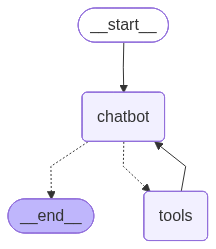

In [18]:
from langgraph.prebuilt import ToolNode, tools_condition        # 사전 구현된 ToolNode / 분기 조건 함수
from typing import TypedDict, Annotated, List                   # 상태 타입 정의용
from langgraph.graph import add_messages,StateGraph,START,END   # 메시지 누적 / 그래프 구성 요소

# 그래프에서 사용할 상태 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages는 add_messages 규칙으로 리스트 누적 저장
    
builder = StateGraph(State) # State 기반 그래피  설계 객체 생성
tool_node = ToolNode(tools) # 바인딩한 tools로 ToolNode 객체 생성

builder.add_node('chatbot',chatbot) # LLM 로출 노드
builder.add_node('tools',tool_node) # 도구 실행 노드

builder.add_edge(START,'chatbot')
builder.add_conditional_edges('chatbot',tools_condition)    # tool call 필요시 tool로, 아니면 END로 분기
builder.add_edge('tools','chatbot') # tools 실행 후 chatbot에서 최종 응답 생성

graph = builder.compile()
graph

In [19]:
user_query = '최근 원화-달러 환율은 어떻게 돼?'
state = {'messages':[('human',user_query)]}
response = graph.invoke(state)
print(response['messages'][-1].content)

최근 원화-달러 환율은 약 1,460원 정도입니다. 구체적으로 1달러당 약 1,460원 선에서 거래되고 있습니다. 더 자세한 실시간 환율은 네이버 금융 등의 금융 정보 사이트에서 확인할 수 있습니다.


In [ ]:
user_query = 'langchain v1.2에서 달라진 점은 뭐야??'
state = {'messages':[('human',user_query)]}
response = await graph.ainvoke(state)   # 그래프 비동기 실행
print(response['messages'][-1].content)

LangChain v1.2에서 달라진 주요 점들은 다음과 같습니다:

1. create_agent 함수: 에이전트를 만들기 위한 새로운 표준 방식으로, 이전의 langgraph.prebuilt.create_react_agent를 대체합니다. 이 함수는 간단한 인터페이스를 제공하면서도 미들웨어를 통한 높은 커스터마이징이 가능합니다.

2. LangChain Middlewares: 에이전트를 생성할 때 여러 가지 미들웨어를 사용할 수 있습니다. 예를 들어, PII(개인 식별 정보) 검출 및 가리기(마스킹)용 PIIMiddleware, 대화 기록 요약용 SummarizationMiddleware, 민감한 도구 호출 시 사용자 승인 요구용 HumanInTheLoopMiddleware 등이 있습니다.

3. 네임스페이스 단순화: langchain 네임스페이스가 에이전트 구축에 필요한 핵심 빌딩 블록 위주로 정리되고, 레거시 기능들은 langchain-classic으로 옮겨졌습니다.

즉, v1.2는 에이전트 생성의 표준화와 확장성 강화, 미들웨어 도입, 그리고 네임스페이스 구조 개선에 중점을 둔 업데이트입니다.


In [22]:
user_query = '파이썬 3.13에서 새롭게 바뀐 내용이 뭐야? context7 too을 사용해 줘'
state = {'messages':[('human',user_query)]}
response = await graph.ainvoke(state)   # 그래프 비동기 실행
print(response['messages'][-1].content)

파이썬 3.13에서 새롭게 바뀐 주요 내용은 다음과 같습니다:

1. 새로운 대화형 인터프리터 도입
2. 실험적인 프리-스레드 모드 지원 (PEP 703)
3. Just-In-Time (JIT) 컴파일러 도입 (PEP 744)
4. 에러 메시지 개선, 기본적으로 컬러 하이라이트된 트레이스백 제공
5. 내장 함수 locals()가 반환하는 매핑 객체에 대해 정의된 의미론 추가
6. 타입 매개변수가 기본값을 지원하게 변경
7. 표준 라이브러리의 오래된 API 및 모듈 다수 제거 (Python 3.11에서 deprecated 되었던 것들)

이 외에도 사용자 친화성과 정확성 개선이 이루어졌습니다.

필요하면 각 항목에 대해 더 자세한 설명도 드릴 수 있습니다.


In [ ]:
user_query = '봄이 시작하는 걸 알려주는 절기가 뭐야?'
state = {'messages':[('human',user_query)]}
response = graph.invoke(state)   # 그래프 실행(도구 호출 없이 사용)
print(response['messages'][-1].content)

봄이 시작하는 걸 알려주는 절기는 "입춘"입니다. 입춘은 24절기 중 첫 번째 절기로, 보통 2월 4일경에 해당하며, 봄의 시작을 알리는 중요한 시기입니다. 이때부터 날씨가 점차 따뜻해지기 시작한다고 여겨집니다.
